In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import cartopy.crs as ccrs
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from math import ceil


from HANZEanalytics.eda.plots import get_europe_canvas, save_fig

In [2]:
root = Path.cwd().parent

events = pd.read_csv(Path(root, "data", "events").with_suffix(".csv"))
regions = gpd.read_file(Path(root, "data", "flood_regions_2021.zip"))

events = events.astype({"ID": int,"Year": int})
events[["Start date", "End date"]] = events[["Start date", "End date"]].apply(pd.to_datetime)

regions = regions.astype({"ID": int, "Year": int, "Start_M": int, "Start_Y": int, "End_M": int, "End_Y": int})

events = events[events["Year"] >= 2000]
regions = regions[regions["Year"] >= 2000]

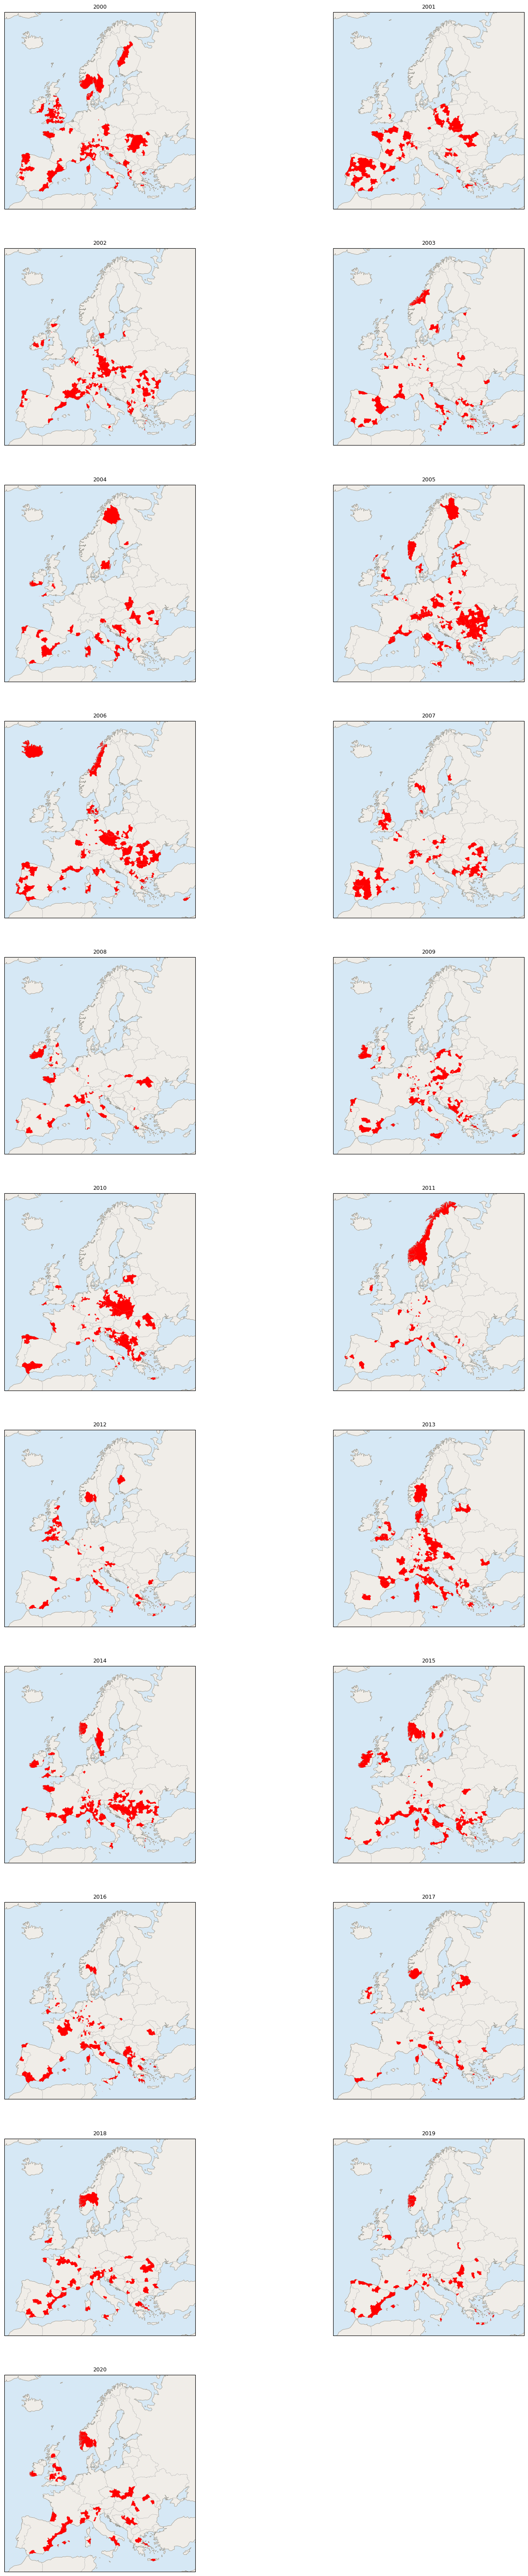

<Figure size 640x480 with 0 Axes>

In [3]:
years = regions["Year"].drop_duplicates().sort_values().to_list()
ncol = 2
nrow = ceil(len(years) / ncol)
fig = plt.figure(figsize=(18, nrow * 7))
gs = gridspec.GridSpec(nrows = nrow, ncols=ncol, figure=fig)

for idx,year in enumerate(years):
    row, col = divmod(idx, ncol)
    ax = fig.add_subplot(gs[row, col], projection=ccrs.epsg(regions.crs.to_epsg()) )
    ax, crs = get_europe_canvas(ax=ax)
    ax.set_title(str(year), fontsize = 9)
    data = regions[regions["Year"] == year]
    data.to_crs(crs).plot(ax=ax, color="red", zorder=4, transform=ccrs.PlateCarree())

plt.show()
save_fig("affected_regions")
